In [29]:
import numpy as np
import matplotlib.pyplot as plt

#### Oppgave 1c

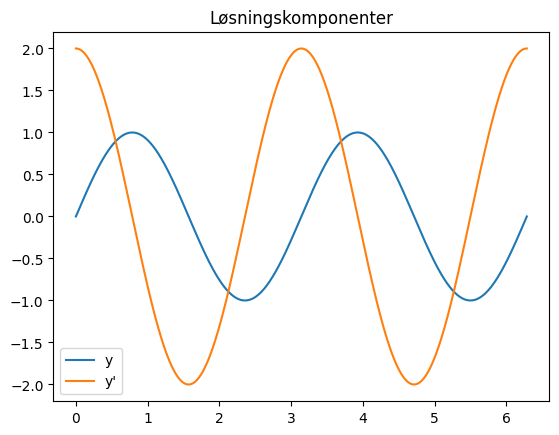

{'Accepted steps': 1070, 'Discarded steps': 1}


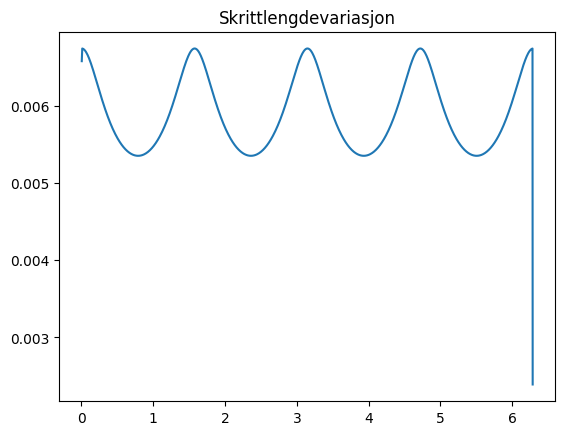

In [30]:
def f(x,y):
    return np.array([y[1], -4*y[0]])

def func(x0, xend, y0, f, h0, tol, alpha):
    x = x0
    h = h0
    y = y0.copy()
    n = 0 #accepted
    nd = 0 #discarded
    k1 = f(x,y)
    X = [x]
    Y = [y0.copy()]

    while xend - x > 0:
        h = min(h, xend - x)
        xn = X[n]
        yn = Y[n]
        xnext = xn + h
        k2 = f(xn + 0.5 * h, yn + 0.5 * h * k1)
        k3 = f(xn + 0.75 * h, yn + 0.75 * h * k2)
        ynext = yn + 1/9 * h * (2 * k1 +3 * k2 +4 * k3)
        k4 = f(xn + h, ynext)
        znext = yn + 1/24 * h * (7 * k1 + 6 * k2 + 8 * k3 + 3 * k4)
        est = np.linalg.norm(ynext - znext)
        if est < tol:
            n += 1
            k1 = k4
            x = x + h
            y = ynext
            X.append(x)
            Y.append(y.copy())
        else:
            nd += 1
        h = alpha * h * (tol/est)**(1/3)
        

    Xa = np.array(X)
    Ya = np.array(Y)
    stats = {"Accepted steps": n, "Discarded steps": nd}
    return Xa, Ya, stats

x0 = 0.0
y0 = np.array([0.0, 2.0])
xend = 2 * np.pi
alpha = 0.8
tol = 1e-7
h0 = 0.1
X, Y, stats = func(x0, xend, y0, f, h0, tol,alpha)

plt.plot(X, Y[:, 0], label = "y")
plt.plot(X, Y[:, 1], label = "y'")
plt.title("Løsningskomponenter")
plt.legend()
plt.show()
print(stats)
plt.plot(X[1:], np.diff(X))
plt.title("Skrittlengdevariasjon")
plt.show()




$est_{n+1} = ||\vec{y}_{n+1} - \vec{z}_{n+1}||$ 

$h_{new} = \alpha * h_n * (tol / est)^{1/3}$ 

Figuren for løsningskomponentene viser hvordan funksjonene til y og y' ser ut. Stats viser at det er 1070 aksepterte steg, og 1 uakseptert steg. 
Plottet for skrittlengdevariasjon viser at skrittene varierer periodisk slik som y og y'. Fra formelen for $est_{n+1}$ og $h_{new}$ ser vi at skrittlengden øker når estimatet blir mindre, og minker når estimatet øker. Dette skjer med en periode på $2\pi$ som kommer fra differensialligningen. 

#### Oppgave 1d

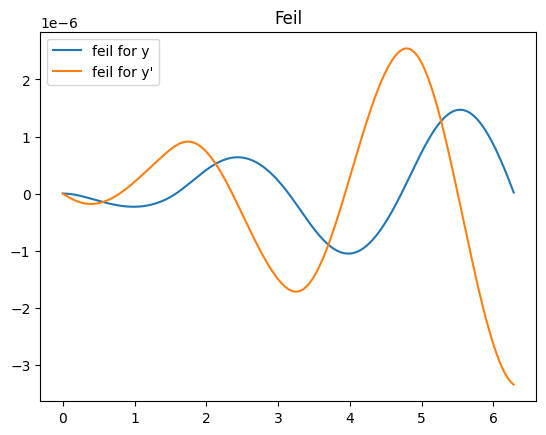

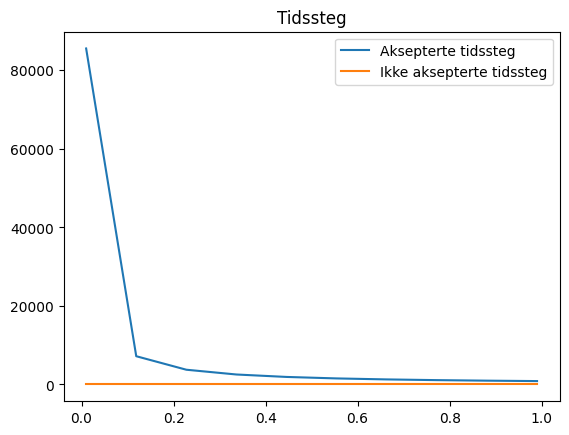

In [31]:
alphas = np.linspace(0.01,0.99, 10)
accepted = []
declined = []
for alpha in alphas:
    X, Y, stats_new = func(x0, xend, y0, f, h0, tol,alpha)
    accepted.append(stats_new["Accepted steps"])
    declined.append(stats_new["Discarded steps"])
    

plt.plot(X, (Y[:, 0] - np.sin(2*X)), label = "feil for y")
plt.plot(X, (Y[:, 1] - 2 * np.cos(2*X)), label = "feil for y'")
plt.legend()
plt.title("Feil")
plt.show()
plt.plot(alphas, accepted, label = "Aksepterte tidssteg")
plt.plot(alphas, declined, label = "Ikke aksepterte tidssteg")

plt.legend()
plt.title("Tidssteg")
plt.show()

Fra den første figuren ser vi at feilen øker med X for begge løsningskomponentene, men feilen er fortsatt veldig liten. Økningen kan skyldes at flere steg/iterasjoner fører til større feil sammenlignet med det analytiske svaret, men at de forsatt er riktige i forhold til hverandre, da variasjonen i feil ligner plottet fra 1c.

Plottet av tiddsteg som variasjon av $\alpha$ viser at de aksepterte stegene blir mindre når $\alpha$ øker, mens de avslåtte tiddstegene alltid er lik 1.